In [1]:
%load_ext autoreload
%autoreload 2

# if you need to install Pybullet:
#   pip3 install Pybullet   (python3)
#   pip install PyBullet    (python2.x)

# let's start with imports
import numpy as np
from numpy.random import seed
from numpy.random import rand
import pybullet as p

from engine_rover import *
from matplotlib import pyplot as plt

# seed random number generator.
seed(1)

%matplotlib inline

pybullet build time: Apr 14 2025 19:37:00


In [2]:
# create a pybullet engine from the engine module
engine = PyBulletEnvironment(gui=True, vacuum_cleaner=True, real_time=True)
#load rover
startPos = [0,0,0]
startOrientation = p.getQuaternionFromEuler([0,0,0])
# robot_urdf = './urdf/shovel/shovelFlat.urdf'
robot_urdf = './urdf/shovel/2_wheel_rover.urdf'

# load the robot
engine.open_environment(robot_urdf, startPos, startOrientation)
engine.set_robot_dim()

startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Intel
GL_RENDERER=Mesa Intel(R) Graphics (RPL-P)
GL_VERSION=4.6 (Core Profile) Mesa 24.2.8-1ubuntu1~24.04.1
GL_SHADING_LANGUAGE_VERSION=4.60
pthread_getconcurrency()=0
Version = 4.6 (Core Profile) Mesa 24.2.8-1ubuntu1~24.04.1
Vendor = Intel
Renderer = Mesa Intel(R) Graphics (RPL-P)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu


In [3]:
minpos = np.array([0.2,-1.5,0])
maxpos = np.array([3, 1.5, 0])
# engine.load_aggregates(minpos, maxpos, 50, './urdf/pebbles/pebbles.urdf')
# engine.load_aggregates_in_clusters(minpos, maxpos, 10, 30, 0.4, './urdf/pebbles/pebbles.urdf')
# Get the number of joints in the robot

# robot info
num_joints = p.getNumJoints(1)
print("Joint names in the robot:")
for joint_index in range(num_joints):
    joint_info = p.getJointInfo(1, joint_index)
    joint_name = joint_info[1].decode('utf-8')  # Joint name is the 2nd element (as bytes, so decode to string)
    print(f"Joint {joint_index}: {joint_name}")

Joint names in the robot:
Joint 0: base_to_front_wheel
Joint 1: base_to_lwheel
Joint 2: base_to_rwheel
Joint 3: base_to_fattach


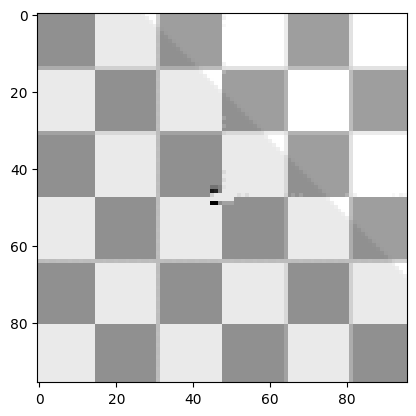

In [4]:
img = engine.get_top_view(pixel_height=320, pixel_width=320, camera_target_pos=[0, 0, 0], camera_distance=5)
img  = cv2.resize(img, (96, 96), interpolation=cv2.INTER_AREA)
img = np.expand_dims(img, 2)
observation = np.asarray(img, dtype="float32") / 255.0
plt.imshow(observation, cmap="gray")
observation = np.moveaxis(observation, -1, 0)

In [5]:
# coordinates
x = 1
y = 2
theta = 0
quadrant = 4

# 1st quadrant
if quadrant == 1:    
    target_pos = np.array([x, y, 0])
    target_quat = p.getQuaternionFromEuler([0, 0, theta])
# 2nd quadrant
elif quadrant == 2:    
    target_pos = np.array([-x, y, 0])
    target_quat = p.getQuaternionFromEuler([0, 0, theta])
# 3rd quadrant
elif quadrant == 3:
    target_pos = np.array([-x, -y, 0])
    target_quat = p.getQuaternionFromEuler([0, 0, theta])
# 4th quadrant
elif quadrant == 4:
    target_pos = np.array([x, -y, 0])
    target_quat = p.getQuaternionFromEuler([0, 0, theta])
else:
    raise ValueError("Invalid quadrant. Must be 1, 2, 3, or 4.")

engine.K1 = 0.5
engine.K2 = 3
engine.K3 = 0.5
engine.control_threshold = 0.2
engine.angle_threshold = 3
engine.vmax = 2
engine.phimax = np.pi
engine.iter_limit = 1e4
engine.control_dt = 5e-3

e_vector, n_iter, = engine.set_positions(target_pos, target_quat)
print("final error: ", e_vector[-1][:], "final iteration: ", n_iter)

final error:  [0.09445765 0.01757368 2.56611106] final iteration:  9115


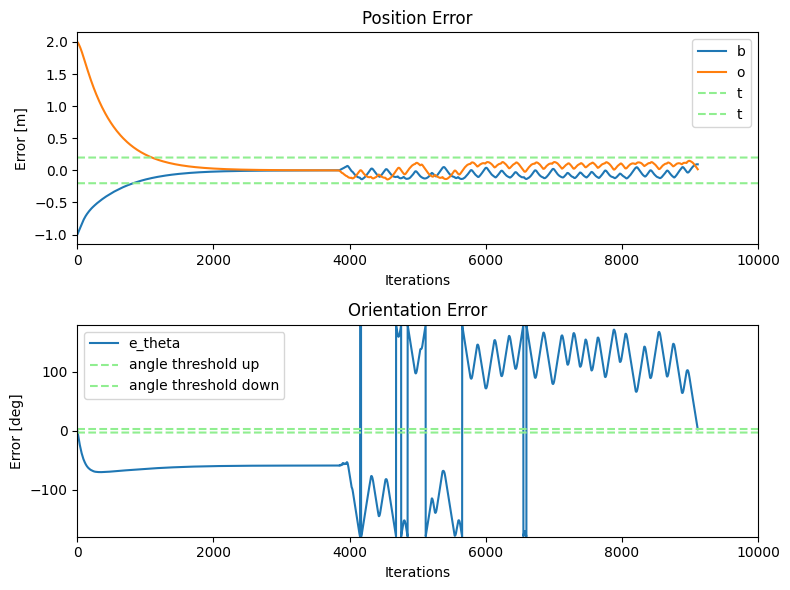

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# First subplot: e_vector[:1] and e_vector[:2]
ax[0].plot(e_vector[:,0], label="e_x")
ax[0].plot(e_vector[:,1], label="e_y")
ax[0].plot(engine.control_threshold * np.ones(int(engine.iter_limit)), label="control threshold up", linestyle='--', color='lightgreen')
ax[0].plot(-engine.control_threshold * np.ones(int(engine.iter_limit)), label="control threshold down", linestyle='--', color='lightgreen')
ax[0].set_title("Position Error")
ax[0].set_xlim(0, engine.iter_limit)
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("Error [m]")
ax[0].legend('bottom right')

# Second subplot: e_vector[:,3]
ax[1].plot(e_vector[:,2], label="e_theta")
ax[1].plot(engine.angle_threshold * np.ones(int(engine.iter_limit)), label="angle threshold up", linestyle='--', color='lightgreen')
ax[1].plot(-engine.angle_threshold * np.ones(int(engine.iter_limit)), label="angle threshold down", linestyle='--', color='lightgreen')
ax[1].set_title("Orientation Error")
ax[1].set_xlim(0, engine.iter_limit)
ax[1].set_ylim(-180, 180)
ax[1].set_xlabel("Iterations")
ax[1].set_ylabel("Error [deg]")
ax[1].legend()

plt.tight_layout()
plt.show()

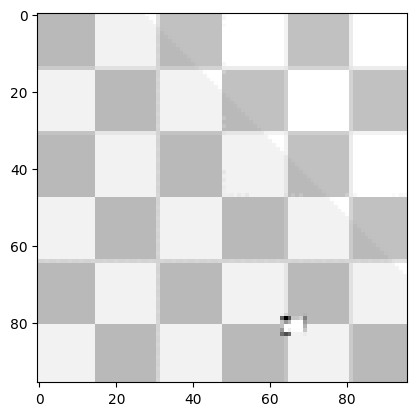

: 

In [ ]:
img = engine.get_top_view(pixel_height=320, pixel_width=320, camera_target_pos=[0, 0, 0], camera_distance=5)
img  = cv2.resize(img, (96, 96), interpolation=cv2.INTER_AREA)
img = np.expand_dims(img, 2)
observation = np.asarray(img, dtype="float32") / 255.0
plt.imshow(observation, cmap="gray")
observation = np.moveaxis(observation, -1, 0)